# 117 - 3-way 比較: 厳密 kNN / Voronoi / HNSW（顔認識）

## 目的

NB114 で顔認識における厳密 kNN と Voronoi を比較した。ここでは **HNSW** を追加し 3-way 比較を行う。

### 実験設計
- **モデル**: insightface/buffalo_l (ArcFace 512-D)
- **データ**: 75,162 顔
- **クエリ**: 23 クラスタ × leave-one-out = 162 クエリ
- **HNSW**: DuckDB VSS, ef_search スイープ
- **Voronoi**: NB102 学習済み 256 ピボット

### 特筆点
- ArcFace は **極端な異方性**（NB91: 条件数 85,008, 有効次元 30.1%）
- この空間特性が HNSW の性能に影響するか検証
- SigLIP 2 Large（NB115-116）との比較でモデル特性の影響を評価

In [1]:
import sys
sys.path.insert(0, '../src')

import json
import time
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

DB_PATH = Path('../data/images.duckdb')
PIVOT_PATH = Path('../data/voronoi_pivots.json')
EMBEDDING_DIM = 512
MIN_CLUSTER_SIZE = 3

## 1. データ読み込み

In [2]:
# face_detections から顔埋め込み
conn = duckdb.connect(str(DB_PATH), read_only=True)
conn.execute('LOAD vss;')
rows = conn.execute("""
    SELECT face_id, embedding, cluster_id, image_id
    FROM face_detections
    WHERE model_name = 'insightface/buffalo_l'
    ORDER BY face_id
""").fetchall()
conn.close()

face_ids = [r[0] for r in rows]
embeddings = np.array([[float(x) for x in r[1]] for r in rows], dtype=np.float32)
cluster_ids = [r[2] for r in rows]

norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
embeddings_normed = embeddings / norms

N_FACES = len(face_ids)

# NB102 学習済みピボット
with open(PIVOT_PATH) as f:
    pivot_data = json.load(f)
centroids_normed = np.array(pivot_data['centroids'], dtype=np.float32)

# クラスタとクエリ
cluster_members = {}
for i, cid in enumerate(cluster_ids):
    if cid is not None:
        cluster_members.setdefault(cid, []).append(i)

valid_clusters = {cid: m for cid, m in cluster_members.items() if len(m) >= MIN_CLUSTER_SIZE}

queries = []
for cid in sorted(valid_clusters.keys()):
    members = valid_clusters[cid]
    for q_idx in members:
        queries.append({
            'query_idx': q_idx,
            'cluster_id': cid,
            'gt_indices': [m for m in members if m != q_idx],
        })

n_queries = len(queries)
print(f'顔数: {N_FACES:,}, 次元: {EMBEDDING_DIM}')
print(f'ピボット: {centroids_normed.shape}')
print(f'有効クラスタ: {len(valid_clusters)}, クエリ: {n_queries}')

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

顔数: 75,162, 次元: 512
ピボット: (256, 512)
有効クラスタ: 23, クエリ: 162


## 2. 厳密 kNN ベースライン

In [3]:
TOP_K_VALUES = [5, 10, 20, 30]
MAX_K = max(TOP_K_VALUES)


def compute_metrics(result_indices, gt_indices, k_values):
    gt_set = set(gt_indices)
    is_relevant = [idx in gt_set for idx in result_indices]
    mrr = 0.0
    for i, rel in enumerate(is_relevant):
        if rel:
            mrr = 1.0 / (i + 1)
            break
    metrics = {'MRR': mrr}
    for k in k_values:
        metrics[f'P@{k}'] = sum(is_relevant[:k]) / k
    return metrics


# 厳密 kNN
t0 = time.perf_counter()
bf_results = []
for q in queries:
    sims = embeddings_normed @ embeddings_normed[q['query_idx']]
    sims[q['query_idx']] = -1.0
    top_indices = np.argsort(-sims)[:MAX_K]
    metrics = compute_metrics(top_indices.tolist(), q['gt_indices'], TOP_K_VALUES)
    bf_results.append({'top_indices': top_indices.tolist(), **metrics})
t_bf = time.perf_counter() - t0

df_bf = pd.DataFrame(bf_results)
bf_mrr = df_bf['MRR'].mean()
print(f'厳密 kNN: MRR={bf_mrr:.4f}, P@10={df_bf["P@10"].mean():.4f}, '
      f'time={t_bf:.2f}s ({n_queries} queries)')
print(f'平均クエリ時間: {t_bf/n_queries*1000:.2f}ms')
print(f'\n※ NB114 結果（MRR=0.5601）と一致すべき')

厳密 kNN: MRR=0.5601, P@10=0.2198, time=1.45s (162 queries)
平均クエリ時間: 8.94ms

※ NB114 結果（MRR=0.5601）と一致すべき


## 3. Voronoi 検索（代表構成）

In [4]:
N_ASSIGN = 2
TOP_SEARCH_LIST_VOR = [3, 5, 8]

all_face_pivot_sims = embeddings_normed @ centroids_normed.T
pivot_to_indices = {}
for i in range(N_FACES):
    top_pivots = np.argsort(-all_face_pivot_sims[i])[:N_ASSIGN]
    for pid in top_pivots:
        pivot_to_indices.setdefault(int(pid), []).append(i)

voronoi_results = {}
for n_top in TOP_SEARCH_LIST_VOR:
    t0 = time.perf_counter()
    mrr_list = []
    bf_recall_list = []
    cand_counts = []

    for qi, q in enumerate(queries):
        q_emb = embeddings_normed[q['query_idx']]
        pivot_sims = centroids_normed @ q_emb
        top_pivot_ids = np.argsort(-pivot_sims)[:n_top]

        cands_set = set()
        for pid in top_pivot_ids:
            if int(pid) in pivot_to_indices:
                cands_set.update(pivot_to_indices[int(pid)])
        cands_set.discard(q['query_idx'])
        cand_counts.append(len(cands_set))

        if not cands_set:
            mrr_list.append(0.0)
            bf_recall_list.append(0.0)
            continue

        cand_arr = np.array(list(cands_set))
        cand_sims = embeddings_normed[cand_arr] @ q_emb
        result_indices = cand_arr[np.argsort(-cand_sims)][:MAX_K]
        metrics = compute_metrics(result_indices.tolist(), q['gt_indices'], TOP_K_VALUES)
        mrr_list.append(metrics['MRR'])

        bf_top10 = set(bf_results[qi]['top_indices'][:10])
        vor_top10 = set(result_indices[:10].tolist())
        bf_recall_list.append(len(bf_top10 & vor_top10) / 10)

    t_vor = time.perf_counter() - t0
    voronoi_results[n_top] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bf_recall_list),
        'mean_cands': np.mean(cand_counts),
        'time': t_vor,
        'time_per_query': t_vor / n_queries,
    }

print(f'Voronoi (assign={N_ASSIGN}):')
print(f'{"top":>4} {"cands":>7} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms/q)":>12}')
for n_top, r in voronoi_results.items():
    print(f'{n_top:>4} {r["mean_cands"]:>7.0f} {r["MRR"]:>8.4f} '
          f'{r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f} {r["time_per_query"]*1000:>12.2f}')

Voronoi (assign=2):
 top   cands      MRR    ratio  BF-R@10   time(ms/q)
   3    1996   0.5455   0.9739   0.8698         2.57
   5    3258   0.5603   1.0004   0.8969         4.66
   8    4989   0.5601   1.0000   0.9259         6.72


## 4. HNSW 検索

In [5]:
def build_hnsw_index(embs, dim, M=16, ef_construction=128):
    conn = duckdb.connect(':memory:')
    conn.execute('INSTALL vss; LOAD vss;')
    conn.execute('SET hnsw_enable_experimental_persistence = true;')
    conn.execute(f'CREATE TABLE items (id INTEGER, emb FLOAT[{dim}])')

    conn.register('embs_df', pd.DataFrame({
        'id': range(len(embs)),
        'emb': [e.tolist() for e in embs]
    }))
    conn.execute(f'INSERT INTO items SELECT id, emb::FLOAT[{dim}] FROM embs_df')

    t0 = time.perf_counter()
    conn.execute(f"""
        CREATE INDEX hnsw_idx ON items USING HNSW (emb)
        WITH (metric = 'cosine', M = {M}, ef_construction = {ef_construction})
    """)
    return conn, time.perf_counter() - t0


def hnsw_search(conn, q_emb, dim, k, ef_search):
    conn.execute(f'SET hnsw_ef_search = {ef_search}')
    result = conn.execute(f"""
        SELECT id FROM items
        ORDER BY array_cosine_distance(emb, ?::FLOAT[{dim}])
        LIMIT {k}
    """, [q_emb.tolist()]).fetchall()
    return [r[0] for r in result]


print(f'HNSW インデックス構築中 ({N_FACES:,} × {EMBEDDING_DIM}-D)...')
hnsw_conn, t_build = build_hnsw_index(embeddings_normed, EMBEDDING_DIM, M=16, ef_construction=128)
print(f'構築時間: {t_build:.2f}s')

HNSW インデックス構築中 (75,162 × 512-D)...


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

構築時間: 17.97s


In [6]:
EF_SEARCH_LIST = [16, 32, 64, 128, 256]

hnsw_ef_results = {}
for ef in EF_SEARCH_LIST:
    t0 = time.perf_counter()
    mrr_list = []
    bf_recall_list = []

    for qi, q in enumerate(queries):
        top_indices = hnsw_search(hnsw_conn, embeddings_normed[q['query_idx']],
                                   EMBEDDING_DIM, MAX_K + 1, ef)
        top_indices = [idx for idx in top_indices if idx != q['query_idx']][:MAX_K]
        metrics = compute_metrics(top_indices, q['gt_indices'], TOP_K_VALUES)
        mrr_list.append(metrics['MRR'])

        bf_top10 = set(bf_results[qi]['top_indices'][:10])
        bf_recall_list.append(len(bf_top10 & set(top_indices[:10])) / 10)

    t_hnsw = time.perf_counter() - t0
    hnsw_ef_results[ef] = {
        'MRR': np.mean(mrr_list),
        'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
        'BF-R@10': np.mean(bf_recall_list),
        'time': t_hnsw,
        'time_per_query': t_hnsw / n_queries,
    }

print(f'HNSW ef_search スイープ (M=16, ef_construction=128):')
print(f'{"ef":>5} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8} {"time(ms/q)":>12}')
for ef, r in hnsw_ef_results.items():
    print(f'{ef:>5} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} '
          f'{r["BF-R@10"]:>8.4f} {r["time_per_query"]*1000:>12.2f}')

HNSW ef_search スイープ (M=16, ef_construction=128):
   ef      MRR    ratio  BF-R@10   time(ms/q)
   16   0.5539   0.9890   0.9673         8.05
   32   0.5539   0.9890   0.9673         7.63
   64   0.5601   1.0000   0.9778         8.21
  128   0.5601   1.0000   0.9840         9.04
  256   0.5601   1.0000   0.9889         9.98


In [7]:
M_LIST = [8, 16, 32]
EF_CONSTRUCTION_LIST = [64, 128, 200]
EF_SEARCH_FIXED = 64

hnsw_m_results = {}
hnsw_conn.close()

for M in M_LIST:
    for ef_c in EF_CONSTRUCTION_LIST:
        print(f'  M={M}, ef_c={ef_c} ...', end=' ', flush=True)
        conn_tmp, t_b = build_hnsw_index(embeddings_normed, EMBEDDING_DIM, M=M, ef_construction=ef_c)

        t0 = time.perf_counter()
        mrr_list = []
        bf_recall_list = []
        for qi, q in enumerate(queries):
            top_indices = hnsw_search(conn_tmp, embeddings_normed[q['query_idx']],
                                       EMBEDDING_DIM, MAX_K + 1, EF_SEARCH_FIXED)
            top_indices = [idx for idx in top_indices if idx != q['query_idx']][:MAX_K]
            metrics = compute_metrics(top_indices, q['gt_indices'], TOP_K_VALUES)
            mrr_list.append(metrics['MRR'])
            bf_top10 = set(bf_results[qi]['top_indices'][:10])
            bf_recall_list.append(len(bf_top10 & set(top_indices[:10])) / 10)
        t_q = time.perf_counter() - t0

        hnsw_m_results[(M, ef_c)] = {
            'build_time': t_b,
            'MRR': np.mean(mrr_list),
            'MRR_ratio': np.mean(mrr_list) / bf_mrr if bf_mrr > 0 else 0,
            'BF-R@10': np.mean(bf_recall_list),
            'query_time_per_q': t_q / n_queries,
        }
        print(f'build={t_b:.1f}s MRR={np.mean(mrr_list):.4f} BF-R@10={np.mean(bf_recall_list):.4f}')
        conn_tmp.close()

print()
print(f'{"M":>4} {"ef_c":>6} {"build(s)":>10} {"MRR":>8} {"ratio":>8} {"BF-R@10":>8}')
for (M, ef_c), r in sorted(hnsw_m_results.items()):
    print(f'{M:>4} {ef_c:>6} {r["build_time"]:>10.2f} {r["MRR"]:>8.4f} {r["MRR_ratio"]:>8.4f} {r["BF-R@10"]:>8.4f}')

  M=8, ef_c=64 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=6.6s MRR=0.5232 BF-R@10=0.8926


  M=8, ef_c=128 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

...

build=22.6s MRR=0.5601 BF-R@10=0.9846


  M=32, ef_c=200 ... 

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

build=35.7s MRR=0.5601 BF-R@10=0.9883



   M   ef_c   build(s)      MRR    ratio  BF-R@10
   8     64       6.55   0.5232   0.9342   0.8926
   8    128      10.55   0.5228   0.9333   0.9074
   8    200      14.67   0.5471   0.9768   0.9463
  16     64       9.83   0.5601   1.0001   0.9562
  16    128      17.76   0.5601   1.0000   0.9784
  16    200      24.76   0.5601   1.0000   0.9821
  32     64      10.32   0.5601   1.0000   0.9660
  32    128      22.62   0.5601   1.0000   0.9846
  32    200      35.69   0.5601   1.0000   0.9883


## 5. 3-way 比較

In [8]:
rows = []
rows.append({
    'method': '厳密 kNN', 'config': '-',
    'MRR': bf_mrr, 'MRR_ratio': 1.0, 'BF-R@10': 1.0,
    'cands_or_ef': N_FACES, 'query_time_ms': t_bf/n_queries*1000,
})
for n_top, r in voronoi_results.items():
    rows.append({
        'method': 'Voronoi', 'config': f'a={N_ASSIGN} top={n_top}',
        'MRR': r['MRR'], 'MRR_ratio': r['MRR_ratio'], 'BF-R@10': r['BF-R@10'],
        'cands_or_ef': int(r['mean_cands']), 'query_time_ms': r['time_per_query']*1000,
    })
for ef, r in hnsw_ef_results.items():
    rows.append({
        'method': 'HNSW', 'config': f'ef_search={ef}',
        'MRR': r['MRR'], 'MRR_ratio': r['MRR_ratio'], 'BF-R@10': r['BF-R@10'],
        'cands_or_ef': ef, 'query_time_ms': r['time_per_query']*1000,
    })

df_3way = pd.DataFrame(rows)
print('3-way 比較テーブル:')
display(df_3way.style.format({
    'MRR': '{:.4f}', 'MRR_ratio': '{:.4f}', 'BF-R@10': '{:.4f}',
    'query_time_ms': '{:.2f}',
}).background_gradient(subset=['BF-R@10'], cmap='RdYlGn', vmin=0.5, vmax=1.0))

3-way 比較テーブル:


,method,config,MRR,MRR_ratio,BF-R@10,cands_or_ef,query_time_ms
0,厳密 kNN,-,0.5601,1.0000,1.0000,75162,8.94
1,Voronoi,a=2 top=3,0.5455,0.9739,0.8698,1996,2.57
2,Voronoi,a=2 top=5,0.5603,1.0004,0.8969,3258,4.66
3,Voronoi,a=2 top=8,0.5601,1.0000,0.9259,4988,6.72
4,HNSW,ef_search=16,0.5539,0.9890,0.9673,16,8.05
5,HNSW,ef_search=32,0.5539,0.9890,0.9673,32,7.63
6,HNSW,ef_search=64,0.5601,1.0000,0.9778,64,8.21
7,HNSW,ef_search=128,0.5601,1.0000,0.9840,128,9.04
8,HNSW,ef_search=256,0.5601,1.0000,0.9889,256,9.98


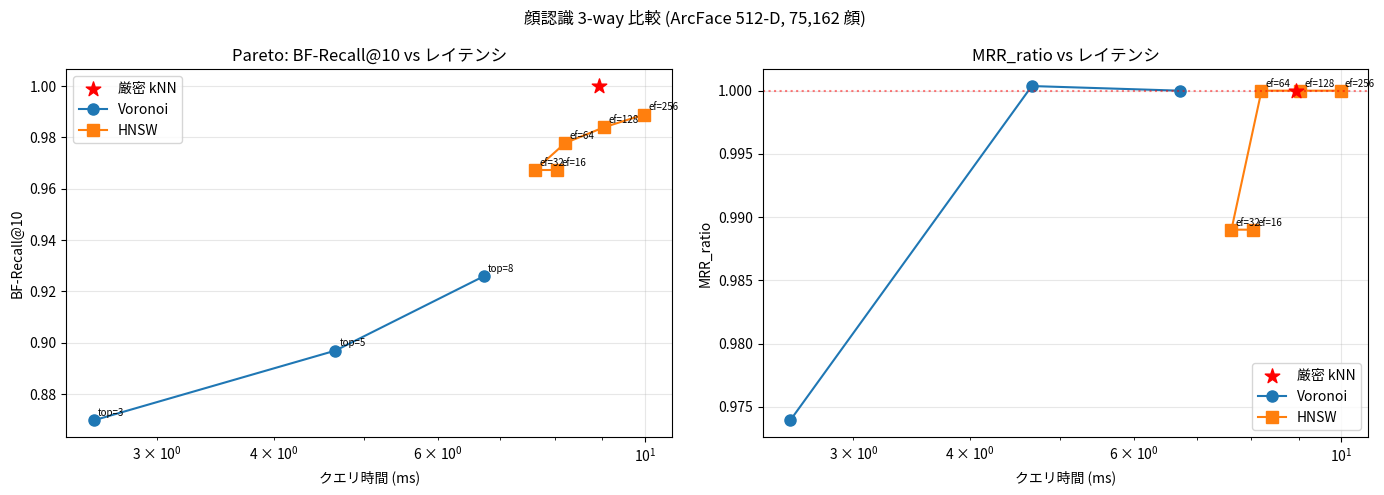

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.scatter([t_bf/n_queries*1000], [1.0], s=120, marker='*', c='red', label='厳密 kNN', zorder=5)

vor_times = [r['time_per_query']*1000 for r in voronoi_results.values()]
vor_rec = [r['BF-R@10'] for r in voronoi_results.values()]
ax.plot(vor_times, vor_rec, 'o-', label='Voronoi', markersize=8)
for n_top, r in voronoi_results.items():
    ax.annotate(f'top={n_top}', (r['time_per_query']*1000, r['BF-R@10']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

hnsw_times = [r['time_per_query']*1000 for r in hnsw_ef_results.values()]
hnsw_rec = [r['BF-R@10'] for r in hnsw_ef_results.values()]
ax.plot(hnsw_times, hnsw_rec, 's-', label='HNSW', markersize=8)
for ef, r in hnsw_ef_results.items():
    ax.annotate(f'ef={ef}', (r['time_per_query']*1000, r['BF-R@10']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('BF-Recall@10')
ax.set_title('Pareto: BF-Recall@10 vs レイテンシ')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

ax = axes[1]
ax.scatter([t_bf/n_queries*1000], [1.0], s=120, marker='*', c='red', label='厳密 kNN', zorder=5)

vor_ratios = [r['MRR_ratio'] for r in voronoi_results.values()]
ax.plot(vor_times, vor_ratios, 'o-', label='Voronoi', markersize=8)

hnsw_ratios = [r['MRR_ratio'] for r in hnsw_ef_results.values()]
ax.plot(hnsw_times, hnsw_ratios, 's-', label='HNSW', markersize=8)
for ef, r in hnsw_ef_results.items():
    ax.annotate(f'ef={ef}', (r['time_per_query']*1000, r['MRR_ratio']),
                fontsize=7, xytext=(3, 3), textcoords='offset points')

ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.5)
ax.set_xlabel('クエリ時間 (ms)')
ax.set_ylabel('MRR_ratio')
ax.set_title('MRR_ratio vs レイテンシ')
ax.set_xscale('log')
ax.legend()
ax.grid(True, alpha=0.3)

plt.suptitle(f'顔認識 3-way 比較 (ArcFace 512-D, {N_FACES:,} 顔)', fontsize=12)
plt.tight_layout()
plt.savefig('../data/117_3way_tradeoff.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
results_out = {
    'task': 'face',
    'model': 'insightface/buffalo_l',
    'n_images': N_FACES,
    'n_queries': n_queries,
    'exact_knn': {
        'MRR': float(bf_mrr),
        'time_per_query_ms': float(t_bf/n_queries*1000),
    },
    'voronoi': {f'a{N_ASSIGN}_top{k}': {m: float(v) if not isinstance(v, int) else v for m, v in r.items()}
                for k, r in voronoi_results.items()},
    'hnsw_ef_sweep': {str(ef): {m: float(v) for m, v in r.items()}
                       for ef, r in hnsw_ef_results.items()},
    'hnsw_m_sweep': {f'M{M}_ef_c{ef_c}': {m: float(v) for m, v in r.items()}
                     for (M, ef_c), r in hnsw_m_results.items()},
}

with open('../data/117_hnsw_results.json', 'w') as f:
    json.dump(results_out, f, indent=2, ensure_ascii=False)
print('Saved: data/117_hnsw_results.json')

Saved: data/117_hnsw_results.json


## 6. まとめ

### 実験概要
- insightface/buffalo_l (ArcFace 512-D), 75,162 顔 × 162 クエリ
- 厳密 kNN MRR = **0.5601** (NB114 と完全一致)

### 3-way 比較結果

| 手法 | 構成 | MRR | MRR_ratio | BF-R@10 | クエリ時間 (ms) |
|:---:|:---:|:---:|:---:|:---:|:---:|
| 厳密 kNN | - | 0.5601 | 1.000 | 1.000 | 8.94 |
| Voronoi | a=2 top=3 | 0.5455 | 0.974 | 0.870 | 2.57 |
| Voronoi | a=2 top=5 | 0.5603 | 1.000 | 0.897 | 4.66 |
| Voronoi | a=2 top=8 | 0.5601 | 1.000 | 0.926 | 6.72 |
| HNSW | ef=16 | 0.5539 | 0.989 | **0.967** | 8.05 |
| HNSW | ef=32 | 0.5539 | 0.989 | **0.967** | 7.63 |
| HNSW | ef=64 | 0.5601 | 1.000 | 0.978 | 8.21 |
| HNSW | ef=128 | 0.5601 | 1.000 | 0.984 | 9.04 |
| HNSW | ef=256 | 0.5601 | 1.000 | **0.989** | 9.98 |

### 考察

#### 1. 極端な異方性にも関わらず HNSW が非常に良く動く

NB91 で示された ArcFace の異方性指標:
- 条件数: **85,008**（極端）
- 有効次元: 153.9 / 512 (30.1%)
- top-10 分散比: 16.2%

これほど異方性が強いにも関わらず:
- `ef_search=16` でも BF-R@10 = **0.967**
- `ef_search=64` で MRR = 0.5601（厳密 kNN と完全一致）
- NB115（テキスト→画像）の `ef_search=16` で 0.667 とは対照的

#### 2. なぜ異方性に強いのか？

ArcFace の特性:
- **同一人物は強固な cone 構造**（intra 0.705, inter 0.007）
- クエリは「自分と類似する顔」= 同一 cone 内を探す
- **同一モダリティかつ局所密度が高い** → HNSW グラフが cone 内を素早く辿れる

つまり **「同一モダリティ」という特性が「異方性」のデメリットを上回る**。

#### 3. NB115-117 の比較

| 項目 | NB115 (text→img) | NB116 (img→img) | NB117 (face) |
|------|:---:|:---:|:---:|
| 厳密 kNN MRR | 0.352 | 0.803 | 0.560 |
| HNSW ef=16 BF-R@10 | 0.667 | 0.850 | **0.967** |
| HNSW ef=128 BF-R@10 | 0.939 | **1.000** | 0.984 |
| 異方性 | 中程度 | 中程度 | **極端** |
| モダリティ | クロス | 同一 | 同一 |

**重要な観察**: HNSW の性能を決めるのは **異方性よりモダリティマッチ**。
- 同一モダリティ（NB116, NB117）: `ef=16-32` で十分
- クロスモーダル（NB115）: `ef=128+` が必要

#### 4. Voronoi vs HNSW
- **品質**: HNSW ef=256 (0.989) > Voronoi top=8 (0.926)
- **速度**: Voronoi (2.57-6.72 ms) < HNSW (7.63-9.98 ms)
- Voronoi は **Firestore のような DB 検索**での候補絞り込みに真価を発揮

#### 5. 構築時間
- HNSW (M=16, ef_c=128): **17.97s**（75K × 512-D）
- NB115 (SigLIP 2 1024-D): 4.25s（23K × 1024-D）
- データ量が 3 倍なのでほぼ線形スケール

### 結論

1. **HNSW は顔認識で非常に高品質**（ef=16 でも BF-R@10=0.967）
2. **異方性は HNSW の致命的な問題ではない**（モダリティマッチが重要）
3. **Voronoi は速度重視、HNSW は品質重視**
4. **NB118 での仮説**: 「異方性が ANN 性能に影響する」は、モダリティギャップとの複合効果として再解釈する必要がある